### First run the main notebook

In [26]:
%%capture
%run ./Image_processing_fundamentals_pt1.ipynb

## Thresholding bacteria

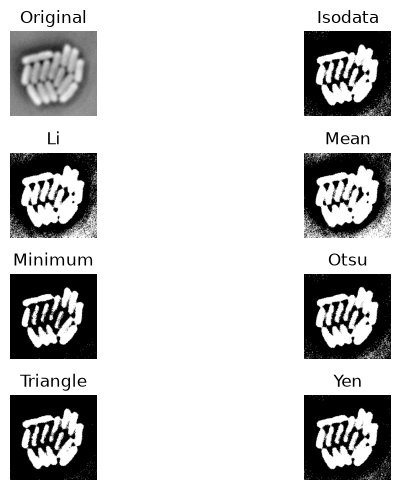

In [10]:
_ = sk.filters.try_all_threshold(img_ecoli, verbose=False)

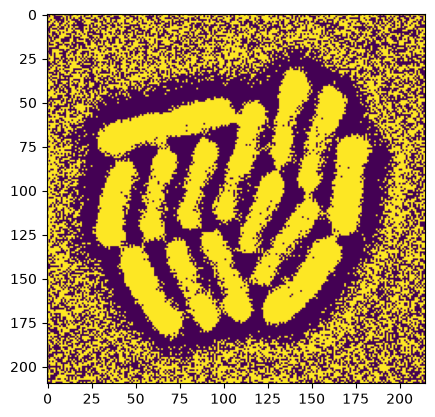

In [18]:
_ = plt.imshow(img_ecoli>sk.filters.threshold_local(img_ecoli, block_size=35, offset=0))

### Conclusion

Some of these results are not bad, but none are directly usable. We'll need more techniques to segment these bacteria.

## Opening and closing

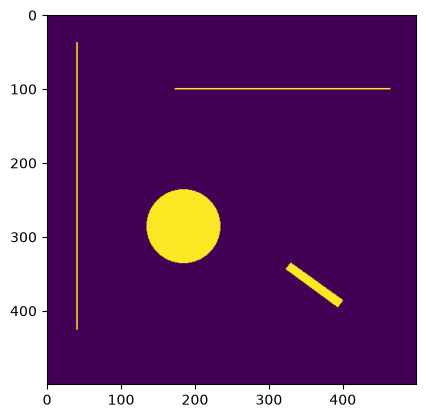

In [20]:
# Morphological closing (dilation followed by erosion)
img_pika_closed = \
    sk.morphology.closing(
        img_pika,
        footprint=sk.morphology.disk(7)
    )

# Show the result
_ = plt.imshow(img_pika_closed) 
plt.show()

This filled the "hole" in the big circle. The footprint modification is needed to achieve this.

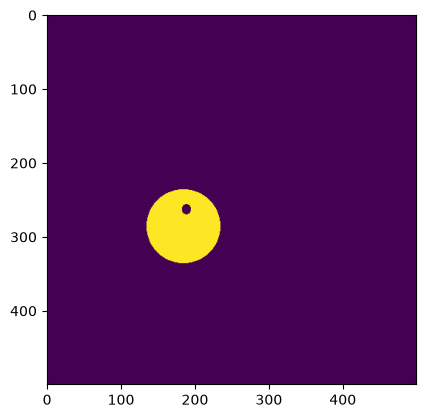

In [22]:
# Morphological opening (erosion followed by dilation)
img_pika_opened = \
    sk.morphology.opening(
        img_pika, 
        footprint=sk.morphology.disk(7)
    )

_ = plt.imshow(img_pika_opened)
plt.show()

This removed everything (due to dilation), but kept the large structure. Also here, depending on the footprint size, different structures remain.

## Thresholding


### Identifying points

> "Can you create a binary mask for the points in `img_noisy`?"

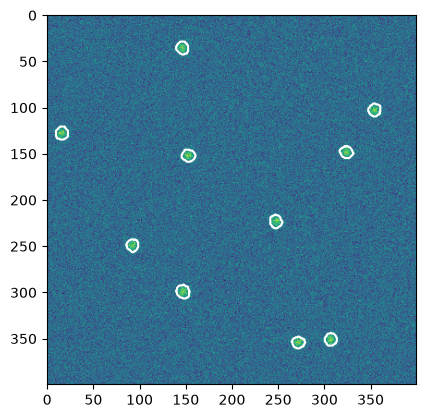

In [ ]:
# Obtain a mask using simple Otsu threshold applied to median filtered image
# The median filtered image will contain high medians only when there was a local
# concentration of higher values, ie the spots.
mask_points = img_noisy_median>sk.filters.threshold_otsu(img_noisy_median)

# Show result
_ = plt.imshow(img_noisy)
_ = plt.contour(mask_points, colors='w', levels=[0.5]) 
    # plt.contour draws isolines at given levels, sometimes convenient for showing segmentation

### Nuclear edges

> "Can you create a binary mask that contains the edges of `img_nuclei`?"

There are many ways to do this, easiest is probably starting from the binary mask of the nuclei, and then getting to their outlines.

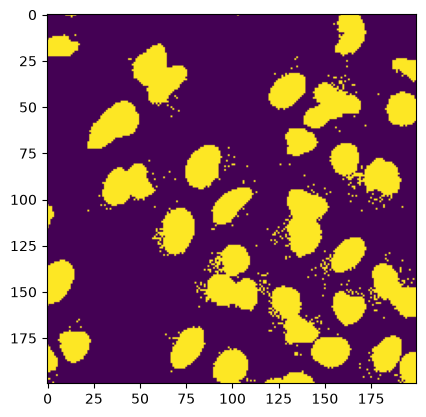

In [72]:
thresh_triangle = sk.filters.threshold_triangle(img_nuclei)
mask_nuclei = img_nuclei > thresh_triangle
_ = plt.imshow(mask_nuclei[0:200,0:200])

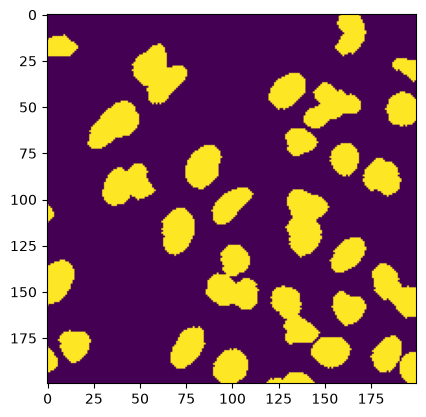

In [94]:
# First remove small features, mophological opening
mask_nuclei_opened = sk.morphology.opening(mask_nuclei, footprint=sk.morphology.disk(2))
_ = plt.imshow(mask_nuclei_closed[0:200,0:200])

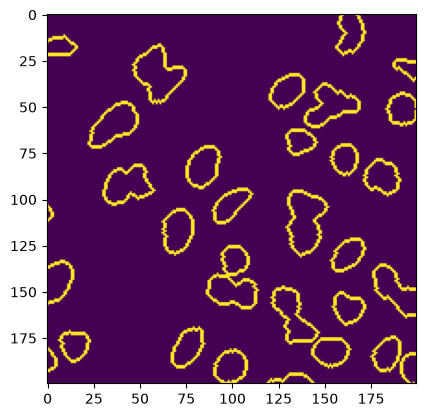

In [ ]:

# Now erode that mask (removing the edges, keeping center parts)
mask_nuclei_eroded = sk.morphology.erosion(mask_nuclei_opened, footprint=sk.morphology.disk(2))
# Then subtract the center parts from the original mask
mask_nuclei_edges  = np.logical_and(mask_nuclei_opened, ~mask_nuclei_eroded)

_ = plt.imshow(mask_nuclei_edges[0:200,0:200])

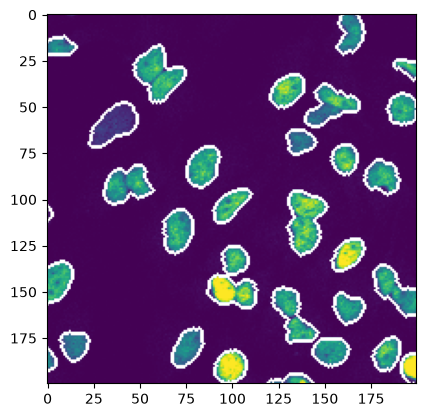

In [ ]:
# Now visualize the result
_ = plt.imshow(img_nuclei[0:200,0:200])
_ = plt.imshow(mask_nuclei_edges[0:200,0:200], 
               alpha = (mask_nuclei_edges[0:200,0:200]>0)*1.0, cmap="gray")
                # We use the "alpha" argument to set transparency of this
                # plot layer. 
                # See also:
                # https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html